# Layer 5: KPI Analytics Notebook

## Manufacturing KPI Framework for Maintenance Leadership

**Audience:** Operations Managers, Maintenance Managers, Reliability Engineers, Plant Leadership  
**Source of Truth:** SQLite database `maintenance.db`  
**Tables Used:** `machine_clean`, `machine_analytics`

This notebook calculates executive-level manufacturing and maintenance KPIs using SQL as the primary data source. Python is used to validate calculations, visualize results, and prepare executive scorecards.

No CSV files are read in this notebook.

In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_PATH = PROJECT_ROOT / "data" / "database" / "maintenance.db"
print(f"Database path: {DATABASE_PATH}")

Database path: C:\Users\Lavanya\Documents\Data analytics\Industrial Equipment Performance & Maintenance Intelligence Analytics Platform\data\database\maintenance.db


In [2]:
def require_database(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(
            f"Database not found at {path}. Run Layer 1 ingestion or Layer 3 cleaning before this KPI notebook."
        )

def run_sql(query: str, params: tuple | None = None) -> pd.DataFrame:
    with sqlite3.connect(DATABASE_PATH) as connection:
        return pd.read_sql_query(query, connection, params=params or ())

def validate_database_tables() -> None:
    required_tables = {"machine_clean", "machine_analytics"}
    with sqlite3.connect(DATABASE_PATH) as connection:
        existing = {
            row[0]
            for row in connection.execute(
                "SELECT name FROM sqlite_master WHERE type IN ('table', 'view');"
            ).fetchall()
        }
    missing = sorted(required_tables - existing)
    if missing:
        raise ValueError(f"Missing required database tables: {missing}")

def annotate_bars(ax, values, fmt="{:.1f}", offset_ratio=0.02) -> None:
    if len(values) == 0:
        return
    max_value = max(values) if max(values) != 0 else 1
    for patch, value in zip(ax.patches, values):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + max_value * offset_ratio,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=9,
        )

def kpi_status(value: float, good_threshold: float, monitor_threshold: float, higher_is_better: bool = True) -> str:
    if higher_is_better:
        if value >= good_threshold:
            return "Good"
        if value >= monitor_threshold:
            return "Monitor"
        return "Critical"
    if value <= good_threshold:
        return "Good"
    if value <= monitor_threshold:
        return "Monitor"
    return "Critical"

require_database(DATABASE_PATH)
validate_database_tables()

In [3]:
base_sql = """
SELECT
    mc.observation_id,
    mc.product_id,
    mc.machine_type,
    mc.machine_failure,
    ma.air_temperature_k,
    ma.process_temperature_k,
    ma.temperature_difference_k,
    ma.rotational_speed_rpm,
    ma.torque_nm,
    ma.mechanical_power_watts,
    ma.tool_wear_min,
    ma.tool_wear_risk_level,
    ma.operating_stress_score,
    ma.failure_mode_count,
    ma.primary_failure_mode,
    ma.twf,
    ma.hdf,
    ma.pwf,
    ma.osf,
    ma.rnf
FROM machine_clean AS mc
INNER JOIN machine_analytics AS ma
    ON mc.observation_id = ma.observation_id;
"""
base_df = run_sql(base_sql)
display(base_df.head())
print(f"Rows loaded from SQLite: {len(base_df):,}")

,observation_id,product_id,machine_type,machine_failure,air_temperature_k,process_temperature_k,temperature_difference_k,rotational_speed_rpm,torque_nm,mechanical_power_watts,tool_wear_min,tool_wear_risk_level,operating_stress_score,failure_mode_count,primary_failure_mode,twf,hdf,pwf,osf,rnf
0,1,M14860,M,0,298.1,308.6,10.5,1551,42.8,6951.5906,0,Low,45.0679,0,No Failure,0,0,0,0,0
1,2,L47181,L,0,298.2,308.7,10.5,1408,46.3,6826.7227,3,Low,46.2314,0,No Failure,0,0,0,0,0
2,3,L47182,L,0,298.1,308.5,10.4,1498,49.4,7749.3875,5,Low,49.4126,0,No Failure,0,0,0,0,0
3,4,L47183,L,0,298.2,308.6,10.4,1433,39.5,5927.5047,7,Low,41.3242,0,No Failure,0,0,0,0,0
4,5,L47184,L,0,298.2,308.7,10.5,1408,40.0,5897.8166,9,Low,42.1695,0,No Failure,0,0,0,0,0


Rows loaded from SQLite: 10,000


## 1. KPI Framework Overview

### Business Purpose

Maintenance KPIs convert machine observations into operational decisions. They help leaders identify whether failures are frequent, whether repair burden is manageable, whether equipment is available for production, and whether operating conditions are creating reliability risk.

### Why KPIs Matter in Predictive Maintenance

- They quantify reliability performance instead of relying on anecdotal maintenance feedback.
- They create shared measures for operations, maintenance, reliability, and plant leadership.
- They provide targets for preventive maintenance, condition monitoring, and reliability improvement.
- They help prioritize scarce technician time and maintenance budget.

### KPI Relationship Model

- **Failure Rate** shows how often failures occur.
- **MTBF** estimates how long the equipment population operates between failures.
- **MTTR** estimates repair burden after a failure.
- **Availability** combines failure frequency and repair burden.
- **Performance** measures operating efficiency using speed, power, and stress.
- **Quality** measures failure-free operation.
- **OEE** combines availability, performance, and quality into one executive effectiveness metric.

### Engineered Feature Mapping

The notebook reuses existing engineered features from `machine_analytics` and does not recreate them:

| Business Feature Name | SQLite Column |
|---|---|
| temperature_difference | `temperature_difference_k` |
| mechanical_power | `mechanical_power_watts` |
| tool_wear_risk_category | `tool_wear_risk_level` |
| operating_stress_score | `operating_stress_score` |
| failure_count | `failure_mode_count` |
| primary_failure_mode | `primary_failure_mode` |

## 2. Overall Failure Rate

### Business Purpose

Failure Rate measures the percentage of observations where machine failure occurred. It is the baseline reliability KPI for the equipment population.

### Formula

`Failure Rate = Total Failed Observations / Total Observations`

### SQL Logic

Count all observations from `machine_analytics`, sum `machine_failure`, and divide failures by total observations.

In [4]:
failure_rate_sql = """
SELECT
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS failed_observations,
    ROUND(1.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 6) AS failure_rate,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent
FROM machine_analytics;
"""
failure_rate_sql_df = run_sql(failure_rate_sql)
display(failure_rate_sql_df)

failure_rate_python = base_df["machine_failure"].sum() / len(base_df)
failure_rate_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "failure_rate": failure_rate_sql_df.loc[0, "failure_rate"]},
        {"method": "Python", "failure_rate": round(failure_rate_python, 6)},
    ]
)
display(failure_rate_compare_df)

,total_observations,failed_observations,failure_rate,failure_rate_percent
0,10000,339,0.0339,3.39


,method,failure_rate
0,SQL,0.0339
1,Python,0.0339


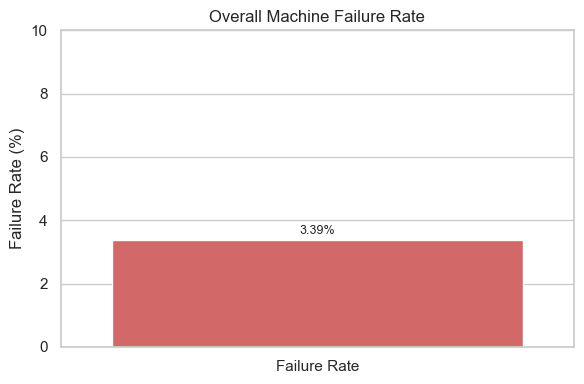

Insight
The equipment population has an observed failure rate of 3.39%.
Recommendation
Use this as the baseline reliability KPI. Any machine type, risk segment, or failure category above this baseline should be prioritized for deeper review.


In [5]:
overall_failure_rate_percent = float(failure_rate_sql_df.loc[0, "failure_rate_percent"])
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Failure Rate"], y=[overall_failure_rate_percent], ax=ax, color="#E45756")
annotate_bars(ax, [overall_failure_rate_percent], fmt="{:.2f}%")
ax.set_ylim(0, max(10, overall_failure_rate_percent * 1.4))
ax.set_title("Overall Machine Failure Rate")
ax.set_ylabel("Failure Rate (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Insight")
print(f"The equipment population has an observed failure rate of {overall_failure_rate_percent:.2f}%.")
print("Recommendation")
print("Use this as the baseline reliability KPI. Any machine type, risk segment, or failure category above this baseline should be prioritized for deeper review.")

## 3. Failure Rate by Machine Type

### Business Purpose

This KPI identifies which machine type has the highest failure exposure so maintenance leaders can prioritize reliability review by equipment segment.

### Formula

`Failure Rate by Machine Type = Failed Observations for Machine Type / Total Observations for Machine Type`

### SQL Logic

Group `machine_analytics` by `machine_type`, sum failures, and divide by observations in each group.

In [6]:
failure_rate_by_type_sql = """
SELECT
    machine_type,
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS failed_observations,
    ROUND(1.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 6) AS failure_rate,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent
FROM machine_analytics
GROUP BY machine_type
ORDER BY failure_rate_percent DESC;
"""
failure_type_sql_df = run_sql(failure_rate_by_type_sql)
display(failure_type_sql_df)

failure_type_python_df = (
    base_df.groupby("machine_type", as_index=False)
    .agg(total_observations=("machine_failure", "size"), failed_observations=("machine_failure", "sum"))
)
failure_type_python_df["failure_rate"] = (
    failure_type_python_df["failed_observations"] / failure_type_python_df["total_observations"]
).round(6)
failure_type_python_df["failure_rate_percent"] = (failure_type_python_df["failure_rate"] * 100).round(4)
failure_type_python_df = failure_type_python_df.sort_values("failure_rate_percent", ascending=False)
display(failure_type_python_df)

,machine_type,total_observations,failed_observations,failure_rate,failure_rate_percent
0,L,6000,235,0.039167,3.9167
1,M,2997,83,0.027694,2.7694
2,H,1003,21,0.020937,2.0937


,machine_type,total_observations,failed_observations,failure_rate,failure_rate_percent
1,L,6000,235,0.039167,3.9167
2,M,2997,83,0.027694,2.7694
0,H,1003,21,0.020937,2.0937


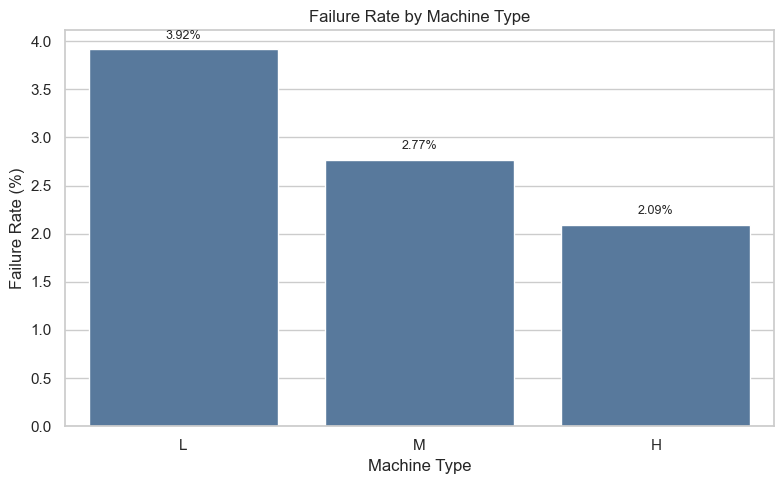

Insight
Machine type L has the highest failure rate at 3.92%.
Recommendation
Prioritize this machine type for preventive maintenance review, operating condition comparison, and root-cause analysis.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=failure_type_sql_df, x="machine_type", y="failure_rate_percent", ax=ax, color="#4C78A8")
annotate_bars(ax, failure_type_sql_df["failure_rate_percent"].tolist(), fmt="{:.2f}%")
ax.set_title("Failure Rate by Machine Type")
ax.set_xlabel("Machine Type")
ax.set_ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

highest_failure_type = failure_type_sql_df.iloc[0]
print("Insight")
print(f"Machine type {highest_failure_type['machine_type']} has the highest failure rate at {highest_failure_type['failure_rate_percent']:.2f}%.")
print("Recommendation")
print("Prioritize this machine type for preventive maintenance review, operating condition comparison, and root-cause analysis.")

## 4. MTBF: Mean Time Between Failures

### Business Purpose

MTBF estimates how long equipment operates between failures. It helps reliability engineers monitor whether failures are becoming more frequent.

### Documented Assumption

The AI4I dataset does not contain timestamps, runtime hours, or production cycles. Therefore, this notebook uses an analytical approximation: **each observation is treated as one normalized operating cycle**.

### Formula

`MTBF Proxy = Total Observations / Total Failed Observations`

### Limitation

This is not real elapsed runtime between failures. It is an observation-based reliability proxy for comparing the dataset population.

In [8]:
mtbf_sql = """
SELECT
    COUNT(*) AS total_observations,
    SUM(machine_failure) AS failed_observations,
    ROUND(1.0 * COUNT(*) / NULLIF(SUM(machine_failure), 0), 4) AS mtbf_normalized_cycles
FROM machine_analytics;
"""
mtbf_sql_df = run_sql(mtbf_sql)
display(mtbf_sql_df)

mtbf_python = len(base_df) / base_df["machine_failure"].sum()
mtbf_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "mtbf_normalized_cycles": mtbf_sql_df.loc[0, "mtbf_normalized_cycles"]},
        {"method": "Python", "mtbf_normalized_cycles": round(mtbf_python, 4)},
    ]
)
display(mtbf_compare_df)

,total_observations,failed_observations,mtbf_normalized_cycles
0,10000,339,29.4985


,method,mtbf_normalized_cycles
0,SQL,29.4985
1,Python,29.4985


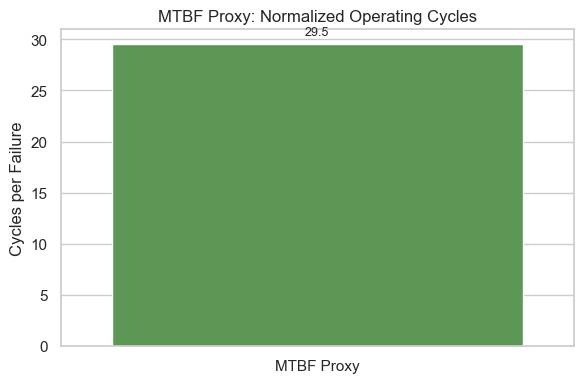

Insight
The observation-based MTBF proxy is 29.5 normalized cycles between failures.
Recommendation
Use this KPI for relative reliability tracking. Replace it with true runtime-based MTBF when timestamped production or maintenance logs become available.


In [9]:
mtbf_value = float(mtbf_sql_df.loc[0, "mtbf_normalized_cycles"])
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["MTBF Proxy"], y=[mtbf_value], ax=ax, color="#54A24B")
annotate_bars(ax, [mtbf_value], fmt="{:.1f}")
ax.set_title("MTBF Proxy: Normalized Operating Cycles")
ax.set_ylabel("Cycles per Failure")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Insight")
print(f"The observation-based MTBF proxy is {mtbf_value:.1f} normalized cycles between failures.")
print("Recommendation")
print("Use this KPI for relative reliability tracking. Replace it with true runtime-based MTBF when timestamped production or maintenance logs become available.")

## 5. MTTR: Mean Time To Repair

### Business Purpose

MTTR estimates average repair effort after a failure. It supports maintenance capacity planning and prioritization by failure category.

### Documented Repair-Time Assumption Model

AI4I does not contain repair duration or downtime. The following assumption model is used only for analytical decision support:

| Failure Mode | Assumed Repair Hours | Business Justification |
|---|---:|---|
| Tool Wear Failure | 3.0 | Tool change, inspection, recalibration, and restart checks. |
| Heat Dissipation Failure | 2.5 | Cooling path inspection, thermal stabilization, and restart validation. |
| Power Failure | 2.0 | Electrical/load inspection and controlled restart. |
| Overstrain Failure | 3.5 | Mechanical stress inspection and possible component review. |
| Random Failure | 1.5 | General troubleshooting with lower assumed average burden. |
| Unclassified Failure | 2.0 | Conservative default for failures without a detailed category. |

### Formula

`MTTR Proxy = Total Assumed Repair Hours / Total Failed Observations`

### Limitation

This is not measured downtime. It is a documented repair burden approximation for KPI demonstration.

In [10]:
repair_hours_map = {
    "Tool Wear Failure": 3.0,
    "Heat Dissipation Failure": 2.5,
    "Power Failure": 2.0,
    "Overstrain Failure": 3.5,
    "Random Failure": 1.5,
    "Unclassified Failure": 2.0,
    "No Failure": 0.0,
}

mttr_sql = """
WITH repair_model AS (
    SELECT
        primary_failure_mode,
        CASE
            WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
            WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
            WHEN primary_failure_mode = 'Power Failure' THEN 2.0
            WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
            WHEN primary_failure_mode = 'Random Failure' THEN 1.5
            WHEN machine_failure = 1 THEN 2.0
            ELSE 0.0
        END AS assumed_repair_hours
    FROM machine_analytics
    WHERE machine_failure = 1
)
SELECT
    COUNT(*) AS failed_observations,
    ROUND(SUM(assumed_repair_hours), 4) AS total_assumed_repair_hours,
    ROUND(SUM(assumed_repair_hours) / NULLIF(COUNT(*), 0), 4) AS mttr_proxy_hours
FROM repair_model;
"""
mttr_sql_df = run_sql(mttr_sql)
display(mttr_sql_df)

failed_df = base_df.loc[base_df["machine_failure"] == 1].copy()
failed_df["assumed_repair_hours"] = failed_df["primary_failure_mode"].map(repair_hours_map).fillna(2.0)
mttr_python = failed_df["assumed_repair_hours"].sum() / len(failed_df)

mttr_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "mttr_proxy_hours": mttr_sql_df.loc[0, "mttr_proxy_hours"]},
        {"method": "Python", "mttr_proxy_hours": round(mttr_python, 4)},
    ]
)
display(mttr_compare_df)

,failed_observations,total_assumed_repair_hours,mttr_proxy_hours
0,339,898.5,2.6504


,method,mttr_proxy_hours
0,SQL,2.6504
1,Python,2.5973


,primary_failure_mode,failure_count,assumed_repair_hours,total_assumed_repair_hours
0,Heat Dissipation Failure,115,2.5,287.5
1,Overstrain Failure,78,3.5,273.0
2,Power Failure,91,2.0,182.0
3,Tool Wear Failure,46,3.0,138.0
4,No Failure,9,2.0,18.0


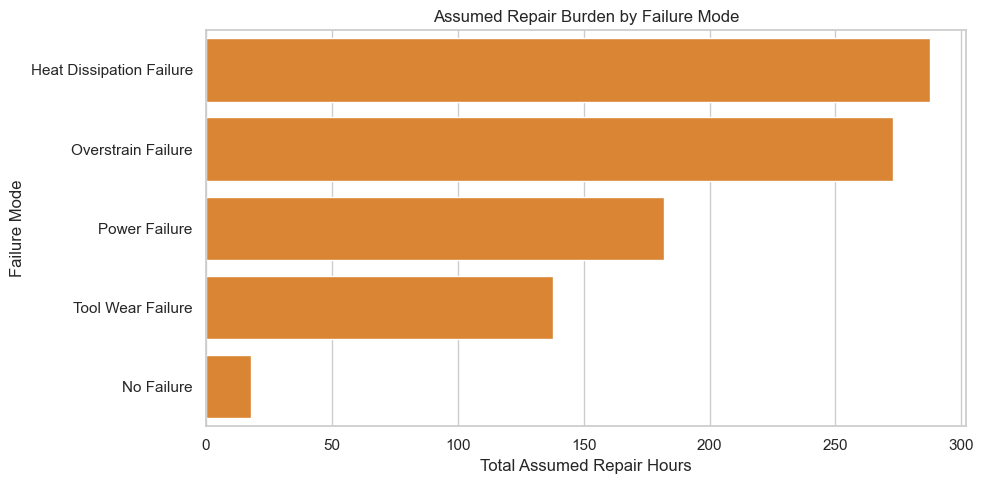

Insight
The documented MTTR proxy is 2.65 assumed repair hours per failed observation.
Recommendation
Use this repair burden model for planning scenarios only. Replace assumptions with actual CMMS repair durations when available.


In [11]:
repair_by_mode_sql = """
SELECT
    primary_failure_mode,
    COUNT(*) AS failure_count,
    CASE
        WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
        WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
        WHEN primary_failure_mode = 'Power Failure' THEN 2.0
        WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
        WHEN primary_failure_mode = 'Random Failure' THEN 1.5
        WHEN machine_failure = 1 THEN 2.0
        ELSE 0.0
    END AS assumed_repair_hours,
    ROUND(COUNT(*) * CASE
        WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
        WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
        WHEN primary_failure_mode = 'Power Failure' THEN 2.0
        WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
        WHEN primary_failure_mode = 'Random Failure' THEN 1.5
        WHEN machine_failure = 1 THEN 2.0
        ELSE 0.0
    END, 4) AS total_assumed_repair_hours
FROM machine_analytics
WHERE machine_failure = 1
GROUP BY primary_failure_mode
ORDER BY total_assumed_repair_hours DESC;
"""
repair_by_mode_df = run_sql(repair_by_mode_sql)
display(repair_by_mode_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=repair_by_mode_df, x="total_assumed_repair_hours", y="primary_failure_mode", ax=ax, color="#F58518")
ax.set_title("Assumed Repair Burden by Failure Mode")
ax.set_xlabel("Total Assumed Repair Hours")
ax.set_ylabel("Failure Mode")
plt.tight_layout()
plt.show()

mttr_value = float(mttr_sql_df.loc[0, "mttr_proxy_hours"])
print("Insight")
print(f"The documented MTTR proxy is {mttr_value:.2f} assumed repair hours per failed observation.")
print("Recommendation")
print("Use this repair burden model for planning scenarios only. Replace assumptions with actual CMMS repair durations when available.")

## 6. Availability

### Business Purpose

Availability estimates the portion of normalized operating capacity not consumed by failures and repair burden.

### Documented Assumption

Because AI4I has no real downtime logs, availability is calculated using the observation-based MTBF proxy and the documented MTTR repair-hour proxy. This is an analytical approximation, not a plant-certified availability metric.

### Formula

`Availability = MTBF / (MTBF + MTTR)`

In [12]:
availability_sql = """
WITH mtbf AS (
    SELECT 1.0 * COUNT(*) / NULLIF(SUM(machine_failure), 0) AS mtbf_normalized_cycles
    FROM machine_analytics
), mttr AS (
    SELECT
        SUM(CASE
            WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
            WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
            WHEN primary_failure_mode = 'Power Failure' THEN 2.0
            WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
            WHEN primary_failure_mode = 'Random Failure' THEN 1.5
            WHEN machine_failure = 1 THEN 2.0
            ELSE 0.0
        END) / NULLIF(COUNT(*), 0) AS mttr_proxy_hours
    FROM machine_analytics
    WHERE machine_failure = 1
)
SELECT
    ROUND(mtbf.mtbf_normalized_cycles, 4) AS mtbf_normalized_cycles,
    ROUND(mttr.mttr_proxy_hours, 4) AS mttr_proxy_hours,
    ROUND(mtbf.mtbf_normalized_cycles / NULLIF(mtbf.mtbf_normalized_cycles + mttr.mttr_proxy_hours, 0), 6) AS availability,
    ROUND(100.0 * mtbf.mtbf_normalized_cycles / NULLIF(mtbf.mtbf_normalized_cycles + mttr.mttr_proxy_hours, 0), 4) AS availability_percent
FROM mtbf CROSS JOIN mttr;
"""
availability_sql_df = run_sql(availability_sql)
display(availability_sql_df)

availability_python = mtbf_python / (mtbf_python + mttr_python)
availability_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "availability": availability_sql_df.loc[0, "availability"]},
        {"method": "Python", "availability": round(availability_python, 6)},
    ]
)
display(availability_compare_df)

,mtbf_normalized_cycles,mttr_proxy_hours,availability,availability_percent
0,29.4985,2.6504,0.917557,91.7557


,method,availability
0,SQL,0.917557
1,Python,0.919075


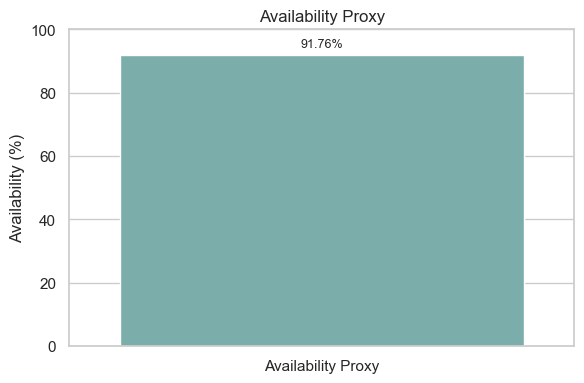

Insight
The availability proxy is 91.76% under the documented MTBF and MTTR assumptions.
Recommendation
Use the metric for executive scenario planning and prioritize collecting actual downtime data for certified availability reporting.


In [13]:
availability_percent = float(availability_sql_df.loc[0, "availability_percent"])
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Availability Proxy"], y=[availability_percent], ax=ax, color="#72B7B2")
annotate_bars(ax, [availability_percent], fmt="{:.2f}%")
ax.set_ylim(0, 100)
ax.set_title("Availability Proxy")
ax.set_ylabel("Availability (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Insight")
print(f"The availability proxy is {availability_percent:.2f}% under the documented MTBF and MTTR assumptions.")
print("Recommendation")
print("Use the metric for executive scenario planning and prioritize collecting actual downtime data for certified availability reporting.")

## 7. Performance Index

### Business Purpose

The Performance Index estimates how effectively equipment is operating using speed, mechanical power, and operating stress.

### Documented Assumptions

AI4I does not contain actual production output or ideal cycle time. Performance is therefore estimated from existing engineered and operating fields.

### Formula

`Performance Index = 0.40 x Speed Ratio + 0.40 x Mechanical Power Ratio + 0.20 x Stress Efficiency`

Where:

- `Speed Ratio = rotational_speed_rpm / max(rotational_speed_rpm)`
- `Mechanical Power Ratio = mechanical_power_watts / max(mechanical_power_watts)`
- `Stress Efficiency = 1 - operating_stress_score / 100`

### SQL Logic

Use window-level maxima from `machine_analytics`, calculate row-level performance, and average across all observations.

In [14]:
performance_sql = """
WITH limits AS (
    SELECT
        MAX(rotational_speed_rpm) AS max_speed,
        MAX(mechanical_power_watts) AS max_power
    FROM machine_analytics
), row_scores AS (
    SELECT
        0.40 * (1.0 * ma.rotational_speed_rpm / NULLIF(limits.max_speed, 0))
        + 0.40 * (ma.mechanical_power_watts / NULLIF(limits.max_power, 0))
        + 0.20 * (1.0 - ma.operating_stress_score / 100.0) AS performance_index
    FROM machine_analytics AS ma
    CROSS JOIN limits
)
SELECT
    ROUND(AVG(performance_index), 6) AS performance_index,
    ROUND(100.0 * AVG(performance_index), 4) AS performance_index_percent
FROM row_scores;
"""
performance_sql_df = run_sql(performance_sql)
display(performance_sql_df)

speed_ratio = base_df["rotational_speed_rpm"] / base_df["rotational_speed_rpm"].max()
power_ratio = base_df["mechanical_power_watts"] / base_df["mechanical_power_watts"].max()
stress_efficiency = 1 - base_df["operating_stress_score"] / 100
base_df["performance_index"] = 0.40 * speed_ratio + 0.40 * power_ratio + 0.20 * stress_efficiency
performance_python = base_df["performance_index"].mean()
performance_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "performance_index": performance_sql_df.loc[0, "performance_index"]},
        {"method": "Python", "performance_index": round(performance_python, 6)},
    ]
)
display(performance_compare_df)

,performance_index,performance_index_percent
0,0.552805,55.2805


,method,performance_index
0,SQL,0.552805
1,Python,0.552805


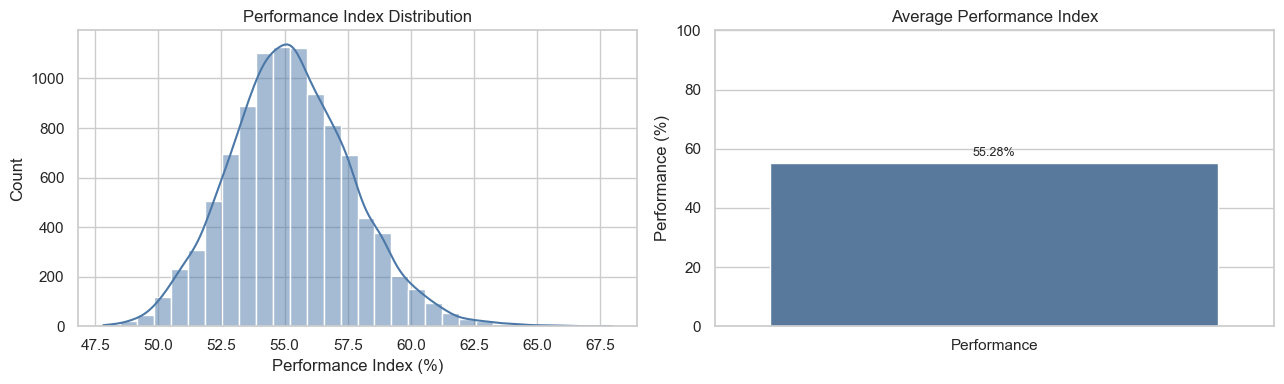

Insight
The performance index is 55.28% based on speed, mechanical power, and stress efficiency.
Recommendation
Use low performance segments to investigate speed loss, load imbalance, and operating stress conditions before they contribute to failures.


In [15]:
performance_percent = float(performance_sql_df.loc[0, "performance_index_percent"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(base_df["performance_index"] * 100, bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Performance Index Distribution")
axes[0].set_xlabel("Performance Index (%)")
sns.barplot(x=["Performance"], y=[performance_percent], ax=axes[1], color="#4C78A8")
annotate_bars(axes[1], [performance_percent], fmt="{:.2f}%")
axes[1].set_ylim(0, 100)
axes[1].set_title("Average Performance Index")
axes[1].set_ylabel("Performance (%)")
plt.tight_layout()
plt.show()

print("Insight")
print(f"The performance index is {performance_percent:.2f}% based on speed, mechanical power, and stress efficiency.")
print("Recommendation")
print("Use low performance segments to investigate speed loss, load imbalance, and operating stress conditions before they contribute to failures.")

## 8. Quality KPI

### Business Purpose

Quality estimates the share of observations that did not experience machine failure.

### Documented Assumption

AI4I does not contain produced units, defective units, scrap, or rework. This notebook uses failure-free observations as a quality proxy.

### Formula

`Quality Proxy = Non-Failure Observations / Total Observations`

### SQL Logic

Count observations with `machine_failure = 0` and divide by total observations.

In [16]:
quality_sql = """
SELECT
    SUM(CASE WHEN machine_failure = 0 THEN 1 ELSE 0 END) AS non_failure_observations,
    COUNT(*) AS total_observations,
    ROUND(1.0 * SUM(CASE WHEN machine_failure = 0 THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0), 6) AS quality_proxy,
    ROUND(100.0 * SUM(CASE WHEN machine_failure = 0 THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0), 4) AS quality_proxy_percent
FROM machine_analytics;
"""
quality_sql_df = run_sql(quality_sql)
display(quality_sql_df)

quality_python = (base_df["machine_failure"] == 0).mean()
quality_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "quality_proxy": quality_sql_df.loc[0, "quality_proxy"]},
        {"method": "Python", "quality_proxy": round(quality_python, 6)},
    ]
)
display(quality_compare_df)

,non_failure_observations,total_observations,quality_proxy,quality_proxy_percent
0,9661,10000,0.9661,96.61


,method,quality_proxy
0,SQL,0.9661
1,Python,0.9661


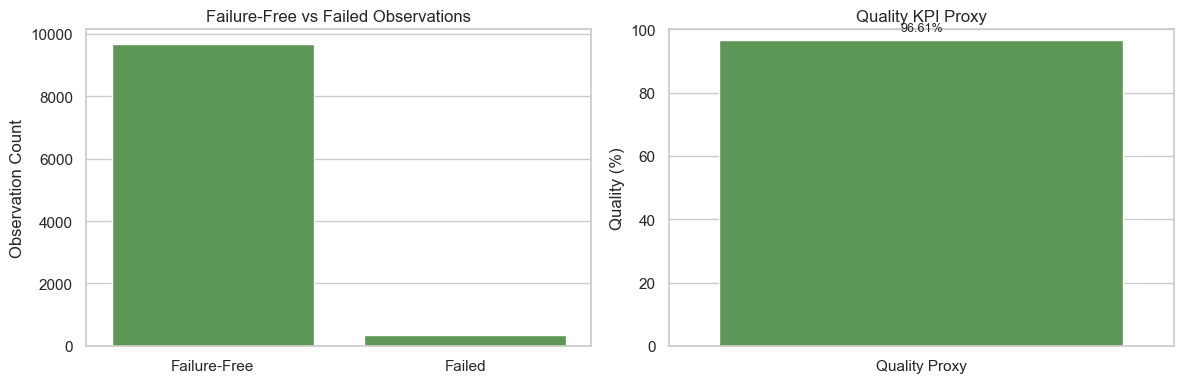

Insight
The failure-free quality proxy is 96.61%.
Recommendation
Use this as a reliability quality indicator only. Add defect and production output data later to calculate true manufacturing quality.


In [17]:
quality_percent = float(quality_sql_df.loc[0, "quality_proxy_percent"])
status_counts = base_df["machine_failure"].map({0: "Failure-Free", 1: "Failed"}).value_counts().reset_index()
status_counts.columns = ["status", "observation_count"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=status_counts, x="status", y="observation_count", ax=axes[0], color="#54A24B")
axes[0].set_title("Failure-Free vs Failed Observations")
axes[0].set_xlabel("")
axes[0].set_ylabel("Observation Count")
sns.barplot(x=["Quality Proxy"], y=[quality_percent], ax=axes[1], color="#54A24B")
annotate_bars(axes[1], [quality_percent], fmt="{:.2f}%")
axes[1].set_ylim(0, 100)
axes[1].set_title("Quality KPI Proxy")
axes[1].set_ylabel("Quality (%)")
plt.tight_layout()
plt.show()

print("Insight")
print(f"The failure-free quality proxy is {quality_percent:.2f}%.")
print("Recommendation")
print("Use this as a reliability quality indicator only. Add defect and production output data later to calculate true manufacturing quality.")

## 9. OEE: Overall Equipment Effectiveness

### Business Purpose

OEE combines availability, performance, and quality into one executive equipment effectiveness KPI.

### Documented Assumptions and Limitations

AI4I is not a production manufacturing dataset with downtime logs, output counts, ideal cycle times, or defect counts. Therefore:

- MTBF is observation-based.
- MTTR uses documented repair-time assumptions.
- Availability is a proxy using MTBF and MTTR approximations.
- Performance uses speed, mechanical power, and stress efficiency.
- Quality uses failure-free observations.
- OEE is an analytical decision-support estimate, not a certified plant OEE measurement.

### Formula

`OEE Proxy = Availability Proxy x Performance Index x Quality Proxy`

In [18]:
oee_sql = """
WITH mtbf AS (
    SELECT 1.0 * COUNT(*) / NULLIF(SUM(machine_failure), 0) AS mtbf_normalized_cycles
    FROM machine_analytics
), mttr AS (
    SELECT
        SUM(CASE
            WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
            WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
            WHEN primary_failure_mode = 'Power Failure' THEN 2.0
            WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
            WHEN primary_failure_mode = 'Random Failure' THEN 1.5
            WHEN machine_failure = 1 THEN 2.0
            ELSE 0.0
        END) / NULLIF(COUNT(*), 0) AS mttr_proxy_hours
    FROM machine_analytics
    WHERE machine_failure = 1
), performance AS (
    WITH limits AS (
        SELECT MAX(rotational_speed_rpm) AS max_speed, MAX(mechanical_power_watts) AS max_power
        FROM machine_analytics
    )
    SELECT AVG(
        0.40 * (1.0 * ma.rotational_speed_rpm / NULLIF(limits.max_speed, 0))
        + 0.40 * (ma.mechanical_power_watts / NULLIF(limits.max_power, 0))
        + 0.20 * (1.0 - ma.operating_stress_score / 100.0)
    ) AS performance_index
    FROM machine_analytics AS ma CROSS JOIN limits
), quality AS (
    SELECT 1.0 * SUM(CASE WHEN machine_failure = 0 THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0) AS quality_proxy
    FROM machine_analytics
)
SELECT
    ROUND(mtbf.mtbf_normalized_cycles / NULLIF(mtbf.mtbf_normalized_cycles + mttr.mttr_proxy_hours, 0), 6) AS availability,
    ROUND(performance.performance_index, 6) AS performance,
    ROUND(quality.quality_proxy, 6) AS quality,
    ROUND(
        (mtbf.mtbf_normalized_cycles / NULLIF(mtbf.mtbf_normalized_cycles + mttr.mttr_proxy_hours, 0))
        * performance.performance_index
        * quality.quality_proxy,
        6
    ) AS oee_proxy,
    ROUND(100.0 *
        (mtbf.mtbf_normalized_cycles / NULLIF(mtbf.mtbf_normalized_cycles + mttr.mttr_proxy_hours, 0))
        * performance.performance_index
        * quality.quality_proxy,
        4
    ) AS oee_proxy_percent
FROM mtbf CROSS JOIN mttr CROSS JOIN performance CROSS JOIN quality;
"""
oee_sql_df = run_sql(oee_sql)
display(oee_sql_df)

oee_python = availability_python * performance_python * quality_python
oee_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "oee_proxy": oee_sql_df.loc[0, "oee_proxy"]},
        {"method": "Python", "oee_proxy": round(oee_python, 6)},
    ]
)
display(oee_compare_df)

,availability,performance,quality,oee_proxy,oee_proxy_percent
0,0.917557,0.552805,0.9661,0.490035,49.0035


,method,oee_proxy
0,SQL,0.490035
1,Python,0.490846


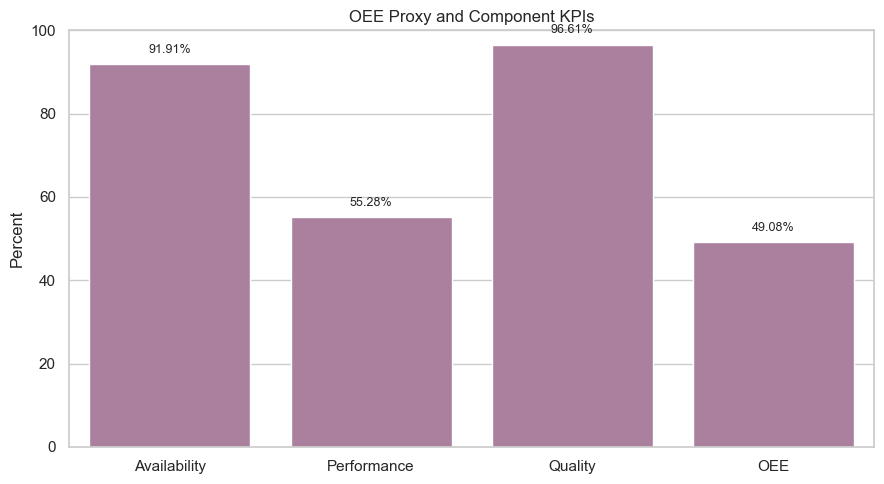

Insight
The OEE proxy is 49.00% under the documented analytical assumptions.
Executive Commentary
This OEE value is useful for comparing scenarios and tracking improvement direction, but it should not be reported as certified plant OEE without production and downtime data.
Recommendation
Use this OEE framework as the executive KPI structure, then replace proxy inputs with actual downtime, output, and quality records as data maturity improves.


In [19]:
oee_components_df = pd.DataFrame(
    {
        "component": ["Availability", "Performance", "Quality", "OEE"],
        "value_percent": [
            availability_python * 100,
            performance_python * 100,
            quality_python * 100,
            oee_python * 100,
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=oee_components_df, x="component", y="value_percent", ax=ax, color="#B279A2")
annotate_bars(ax, oee_components_df["value_percent"].tolist(), fmt="{:.2f}%")
ax.set_ylim(0, 100)
ax.set_title("OEE Proxy and Component KPIs")
ax.set_xlabel("")
ax.set_ylabel("Percent")
plt.tight_layout()
plt.show()

oee_percent = float(oee_sql_df.loc[0, "oee_proxy_percent"])
print("Insight")
print(f"The OEE proxy is {oee_percent:.2f}% under the documented analytical assumptions.")
print("Executive Commentary")
print("This OEE value is useful for comparing scenarios and tracking improvement direction, but it should not be reported as certified plant OEE without production and downtime data.")
print("Recommendation")
print("Use this OEE framework as the executive KPI structure, then replace proxy inputs with actual downtime, output, and quality records as data maturity improves.")

## 10. Machine Reliability Score

### Business Purpose

Machine Reliability Score converts failure history, wear risk, stress, and failure signals into a 0-100 score that is easy for leadership to interpret.

### Formula

`Reliability Score = 100 - Failure Penalty - Wear Penalty - Stress Penalty - Failure Signal Penalty`

Where:

- Failure Penalty = `35` if `machine_failure = 1`, else `0`
- Wear Penalty = `20` for High, `10` for Medium, `0` for Low
- Stress Penalty = `operating_stress_score x 0.25`
- Failure Signal Penalty = `failure_mode_count x 5`

Scores are capped between `0` and `100`.

### Categories

- Excellent: `>= 90`
- Good: `75-89.99`
- Moderate: `60-74.99`
- Poor: `40-59.99`
- Critical: `< 40`

In [20]:
reliability_sql = """
WITH scored AS (
    SELECT
        observation_id,
        machine_type,
        machine_failure,
        tool_wear_risk_level,
        operating_stress_score,
        failure_mode_count,
        MAX(0, MIN(100,
            100
            - CASE WHEN machine_failure = 1 THEN 35 ELSE 0 END
            - CASE
                WHEN tool_wear_risk_level = 'High' THEN 20
                WHEN tool_wear_risk_level = 'Medium' THEN 10
                ELSE 0
              END
            - operating_stress_score * 0.25
            - failure_mode_count * 5
        )) AS machine_reliability_score
    FROM machine_analytics
)
SELECT
    ROUND(AVG(machine_reliability_score), 4) AS avg_machine_reliability_score,
    ROUND(MIN(machine_reliability_score), 4) AS min_machine_reliability_score,
    ROUND(MAX(machine_reliability_score), 4) AS max_machine_reliability_score
FROM scored;
"""
reliability_sql_df = run_sql(reliability_sql)
display(reliability_sql_df)

wear_penalty = base_df["tool_wear_risk_level"].map({"High": 20, "Medium": 10, "Low": 0}).fillna(0)
base_df["machine_reliability_score"] = (
    100
    - np.where(base_df["machine_failure"] == 1, 35, 0)
    - wear_penalty
    - base_df["operating_stress_score"] * 0.25
    - base_df["failure_mode_count"] * 5
).clip(lower=0, upper=100)

reliability_python = base_df["machine_reliability_score"].mean()
reliability_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "avg_machine_reliability_score": reliability_sql_df.loc[0, "avg_machine_reliability_score"]},
        {"method": "Python", "avg_machine_reliability_score": round(reliability_python, 4)},
    ]
)
display(reliability_compare_df)

,avg_machine_reliability_score,min_machine_reliability_score,max_machine_reliability_score
0,80.8248,11.459,96.2721


,method,avg_machine_reliability_score
0,SQL,80.8248
1,Python,80.8248


,reliability_category,observation_count
0,Excellent,1492
1,Good,6437
2,Moderate,1732
3,Poor,137
4,Critical,202


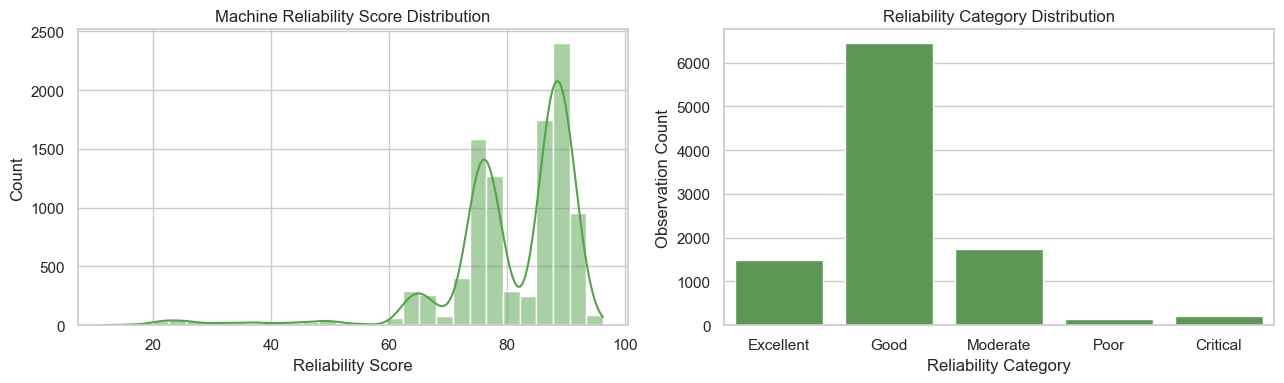

Insight
The average machine reliability score is 80.82 out of 100.
Recommendation
Use Poor and Critical reliability groups as a preventive maintenance watchlist and review the underlying stress, wear, and failure drivers.


In [21]:
def reliability_category(score: float) -> str:
    if score >= 90:
        return "Excellent"
    if score >= 75:
        return "Good"
    if score >= 60:
        return "Moderate"
    if score >= 40:
        return "Poor"
    return "Critical"

base_df["reliability_category"] = base_df["machine_reliability_score"].apply(reliability_category)
reliability_distribution_df = (
    base_df["reliability_category"].value_counts().reindex(["Excellent", "Good", "Moderate", "Poor", "Critical"]).fillna(0).reset_index()
)
reliability_distribution_df.columns = ["reliability_category", "observation_count"]
display(reliability_distribution_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(base_df["machine_reliability_score"], bins=30, kde=True, ax=axes[0], color="#54A24B")
axes[0].set_title("Machine Reliability Score Distribution")
axes[0].set_xlabel("Reliability Score")
sns.barplot(data=reliability_distribution_df, x="reliability_category", y="observation_count", ax=axes[1], color="#54A24B")
axes[1].set_title("Reliability Category Distribution")
axes[1].set_xlabel("Reliability Category")
axes[1].set_ylabel("Observation Count")
plt.tight_layout()
plt.show()

avg_reliability_score = float(reliability_sql_df.loc[0, "avg_machine_reliability_score"])
print("Insight")
print(f"The average machine reliability score is {avg_reliability_score:.2f} out of 100.")
print("Recommendation")
print("Use Poor and Critical reliability groups as a preventive maintenance watchlist and review the underlying stress, wear, and failure drivers.")

## 11. Maintenance Burden Index

### Business Purpose

Maintenance Burden Index estimates how much maintenance workload is created by failure frequency, assumed repair effort, and operating stress.

### Formula

`Maintenance Burden Index = Failure Rate x 40 + MTTR Proxy Hours x 10 + Average Operating Stress Score x 0.30`

### Business Meaning

Higher values indicate more maintenance capacity pressure. This KPI is best used for prioritization and trend monitoring, not as a measured labor-hour value.

In [22]:
maintenance_burden_sql = """
WITH base AS (
    SELECT
        1.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0) AS failure_rate,
        AVG(operating_stress_score) AS avg_operating_stress_score
    FROM machine_analytics
), mttr AS (
    SELECT
        SUM(CASE
            WHEN primary_failure_mode = 'Tool Wear Failure' THEN 3.0
            WHEN primary_failure_mode = 'Heat Dissipation Failure' THEN 2.5
            WHEN primary_failure_mode = 'Power Failure' THEN 2.0
            WHEN primary_failure_mode = 'Overstrain Failure' THEN 3.5
            WHEN primary_failure_mode = 'Random Failure' THEN 1.5
            WHEN machine_failure = 1 THEN 2.0
            ELSE 0.0
        END) / NULLIF(COUNT(*), 0) AS mttr_proxy_hours
    FROM machine_analytics
    WHERE machine_failure = 1
)
SELECT
    ROUND(base.failure_rate, 6) AS failure_rate,
    ROUND(mttr.mttr_proxy_hours, 4) AS mttr_proxy_hours,
    ROUND(base.avg_operating_stress_score, 4) AS avg_operating_stress_score,
    ROUND(base.failure_rate * 40 + mttr.mttr_proxy_hours * 10 + base.avg_operating_stress_score * 0.30, 4) AS maintenance_burden_index
FROM base CROSS JOIN mttr;
"""
burden_sql_df = run_sql(maintenance_burden_sql)
display(burden_sql_df)

burden_python = failure_rate_python * 40 + mttr_python * 10 + base_df["operating_stress_score"].mean() * 0.30
burden_compare_df = pd.DataFrame(
    [
        {"method": "SQL", "maintenance_burden_index": burden_sql_df.loc[0, "maintenance_burden_index"]},
        {"method": "Python", "maintenance_burden_index": round(burden_python, 4)},
    ]
)
display(burden_compare_df)

,failure_rate,mttr_proxy_hours,avg_operating_stress_score,maintenance_burden_index
0,0.0339,2.6504,50.1928,42.9183


,method,maintenance_burden_index
0,SQL,42.9183
1,Python,42.3873


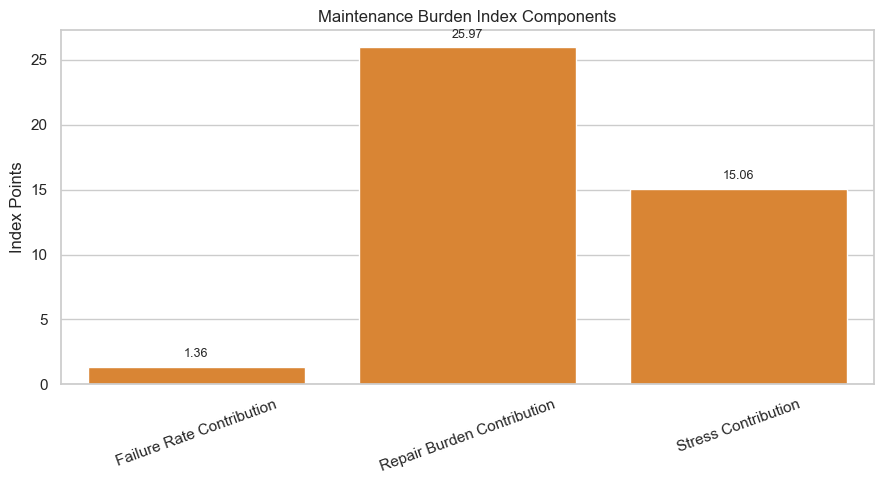

Insight
The Maintenance Burden Index is 42.92 points.
Recommendation
Reduce the burden by targeting the largest component first: failure frequency, repair assumptions by mode, or operating stress exposure.


In [23]:
burden_value = float(burden_sql_df.loc[0, "maintenance_burden_index"])
burden_components_df = pd.DataFrame(
    {
        "component": ["Failure Rate Contribution", "Repair Burden Contribution", "Stress Contribution"],
        "index_points": [failure_rate_python * 40, mttr_python * 10, base_df["operating_stress_score"].mean() * 0.30],
    }
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=burden_components_df, x="component", y="index_points", ax=ax, color="#F58518")
annotate_bars(ax, burden_components_df["index_points"].tolist(), fmt="{:.2f}")
ax.set_title("Maintenance Burden Index Components")
ax.set_xlabel("")
ax.set_ylabel("Index Points")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Insight")
print(f"The Maintenance Burden Index is {burden_value:.2f} points.")
print("Recommendation")
print("Reduce the burden by targeting the largest component first: failure frequency, repair assumptions by mode, or operating stress exposure.")

## 12. Risk Distribution Summary

### Business Purpose

Risk Distribution shows how much of the equipment population is operating in Low, Medium, or High risk states.

### Formula and Segmentation Logic

Risk categories use existing `tool_wear_risk_level`, `operating_stress_score`, and failure signals from `machine_analytics`:

- High Risk: failed observation, High tool wear, operating stress `>= 70`, or multiple failure signals.
- Medium Risk: Medium tool wear, operating stress `>= 45`, or one failure signal.
- Low Risk: all remaining observations.

### SQL Logic

Classify each observation into a risk band and calculate observation share and failure rate by band.

In [24]:
risk_distribution_sql = """
WITH classified AS (
    SELECT
        CASE
            WHEN machine_failure = 1
              OR tool_wear_risk_level = 'High'
              OR operating_stress_score >= 70
              OR failure_mode_count > 1 THEN 'High Risk'
            WHEN tool_wear_risk_level = 'Medium'
              OR operating_stress_score >= 45
              OR failure_mode_count = 1 THEN 'Medium Risk'
            ELSE 'Low Risk'
        END AS risk_category,
        machine_failure
    FROM machine_analytics
), totals AS (
    SELECT COUNT(*) AS total_observations FROM classified
)
SELECT
    risk_category,
    COUNT(*) AS observation_count,
    SUM(machine_failure) AS failed_observations,
    ROUND(100.0 * COUNT(*) / NULLIF(totals.total_observations, 0), 4) AS observation_share_percent,
    ROUND(100.0 * SUM(machine_failure) / NULLIF(COUNT(*), 0), 4) AS failure_rate_percent
FROM classified CROSS JOIN totals
GROUP BY risk_category
ORDER BY
    CASE risk_category
        WHEN 'High Risk' THEN 1
        WHEN 'Medium Risk' THEN 2
        ELSE 3
    END;
"""
risk_distribution_df = run_sql(risk_distribution_sql)
display(risk_distribution_df)

conditions = [
    (base_df["machine_failure"] == 1)
    | (base_df["tool_wear_risk_level"] == "High")
    | (base_df["operating_stress_score"] >= 70)
    | (base_df["failure_mode_count"] > 1),
    (base_df["tool_wear_risk_level"] == "Medium")
    | (base_df["operating_stress_score"] >= 45)
    | (base_df["failure_mode_count"] == 1),
]
base_df["risk_category"] = np.select(conditions, ["High Risk", "Medium Risk"], default="Low Risk")
risk_python_df = (
    base_df.groupby("risk_category", as_index=False)
    .agg(observation_count=("machine_failure", "size"), failed_observations=("machine_failure", "sum"))
)
risk_python_df["observation_share_percent"] = (100 * risk_python_df["observation_count"] / len(base_df)).round(4)
risk_python_df["failure_rate_percent"] = (100 * risk_python_df["failed_observations"] / risk_python_df["observation_count"]).round(4)
display(risk_python_df)

,risk_category,observation_count,failed_observations,observation_share_percent,failure_rate_percent
0,High Risk,1159,339,11.59,29.2494
1,Medium Risk,6261,0,62.61,0.0000
2,Low Risk,2580,0,25.80,0.0000


,risk_category,observation_count,failed_observations,observation_share_percent,failure_rate_percent
0,High Risk,1159,339,11.59,29.2494
1,Low Risk,2580,0,25.80,0.0000
2,Medium Risk,6261,0,62.61,0.0000


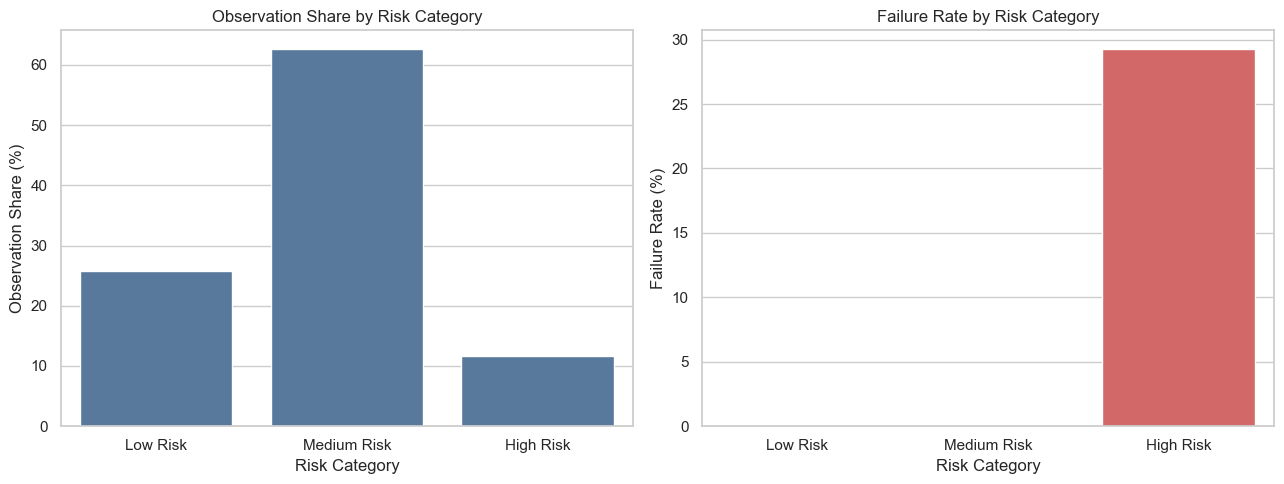

Insight
High Risk observations represent 11.59% of the population and have a 29.25% failure rate.
Recommendation
Use High Risk observations as the first population for preventive maintenance scheduling, reliability review, and Power BI exception reporting.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
risk_order = ["Low Risk", "Medium Risk", "High Risk"]
sns.barplot(data=risk_distribution_df, x="risk_category", y="observation_share_percent", order=risk_order, ax=axes[0], color="#4C78A8")
axes[0].set_title("Observation Share by Risk Category")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Observation Share (%)")
sns.barplot(data=risk_distribution_df, x="risk_category", y="failure_rate_percent", order=risk_order, ax=axes[1], color="#E45756")
axes[1].set_title("Failure Rate by Risk Category")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Failure Rate (%)")
plt.tight_layout()
plt.show()

high_risk_row = risk_distribution_df.loc[risk_distribution_df["risk_category"] == "High Risk"].iloc[0]
print("Insight")
print(f"High Risk observations represent {high_risk_row['observation_share_percent']:.2f}% of the population and have a {high_risk_row['failure_rate_percent']:.2f}% failure rate.")
print("Recommendation")
print("Use High Risk observations as the first population for preventive maintenance scheduling, reliability review, and Power BI exception reporting.")

## 13. Executive KPI Summary

This section converts KPI outputs into leadership-ready findings, risks, opportunities, recommended maintenance actions, and an executive KPI scorecard.

In [26]:
top_kpi_findings = [
    f"Overall failure rate is {overall_failure_rate_percent:.2f}% across {int(failure_rate_sql_df.loc[0, 'total_observations']):,} observations.",
    f"Machine type {highest_failure_type['machine_type']} has the highest failure rate at {highest_failure_type['failure_rate_percent']:.2f}%.",
    f"MTBF proxy is {mtbf_value:.1f} normalized cycles between failures under the documented observation-cycle assumption.",
    f"OEE proxy is {oee_percent:.2f}% using proxy availability, performance, and quality assumptions.",
    f"Average machine reliability score is {avg_reliability_score:.2f} out of 100.",
]

top_risks = [
    "The AI4I dataset does not contain actual downtime, repair duration, production output, or defect counts.",
    "High Risk observations combine failure history, tool wear, stress, and failure signals.",
    f"The highest-failure machine type is {highest_failure_type['machine_type']}, which may require targeted operating review.",
    "MTTR and OEE are assumption-based and should be replaced with CMMS and production data when available.",
    "Poor or Critical reliability categories should be treated as maintenance watchlist candidates.",
]

top_opportunities = [
    "Create a dashboard that tracks failure rate, OEE proxy, and reliability score by machine type.",
    "Use tool wear and operating stress to trigger preventive maintenance inspections.",
    "Capture actual repair duration to convert MTTR from proxy to measured KPI.",
    "Add production output and defect data to calculate certified Performance, Quality, and OEE.",
    "Use reliability score categories to prioritize maintenance backlog and escalation workflows.",
]

recommended_actions = [
    "Prioritize High Risk and low reliability observations for preventive maintenance review.",
    "Investigate the highest-failure machine type for operating condition differences and failure concentration.",
    "Validate repair-time assumptions with maintenance managers before using MTTR for planning decisions.",
    "Implement Power BI KPI cards for failure rate, MTBF proxy, MTTR proxy, availability, OEE, and reliability score.",
    "Build a data maturity roadmap to add downtime, repair logs, production counts, and quality outcomes.",
]

expected_impact = [
    "Improved maintenance prioritization through clear risk segmentation.",
    "Reduced unplanned downtime risk by focusing on high-risk operating profiles.",
    "Better leadership visibility into reliability and maintenance burden.",
    "More defensible KPI reporting because assumptions are documented and not presented as real measurements.",
    "Stronger foundation for predictive maintenance modeling and Power BI executive reporting.",
]

executive_summary_df = pd.DataFrame(
    {
        "Top KPI Findings": top_kpi_findings,
        "Top Risks": top_risks,
        "Top Opportunities": top_opportunities,
        "Recommended Maintenance Actions": recommended_actions,
        "Expected Operational Impact": expected_impact,
    }
)
display(executive_summary_df)

,Top KPI Findings,Top Risks,Top Opportunities,Recommended Maintenance Actions,Expected Operational Impact
0,"Overall failure rate is 3.39% across 10,000 ob...",The AI4I dataset does not contain actual downt...,"Create a dashboard that tracks failure rate, O...",Prioritize High Risk and low reliability obser...,Improved maintenance prioritization through cl...
1,Machine type L has the highest failure rate at...,High Risk observations combine failure history...,Use tool wear and operating stress to trigger ...,Investigate the highest-failure machine type f...,Reduced unplanned downtime risk by focusing on...
2,MTBF proxy is 29.5 normalized cycles between f...,"The highest-failure machine type is L, which m...",Capture actual repair duration to convert MTTR...,Validate repair-time assumptions with maintena...,Better leadership visibility into reliability ...
3,"OEE proxy is 49.00% using proxy availability, ...",MTTR and OEE are assumption-based and should b...,Add production output and defect data to calcu...,"Implement Power BI KPI cards for failure rate,...",More defensible KPI reporting because assumpti...
4,Average machine reliability score is 80.82 out...,Poor or Critical reliability categories should...,Use reliability score categories to prioritize...,"Build a data maturity roadmap to add downtime,...",Stronger foundation for predictive maintenance...


In [27]:
scorecard_rows = [
    {
        "KPI Name": "Failure Rate",
        "Value": f"{overall_failure_rate_percent:.2f}%",
        "Target Benchmark": "<= 3.00%",
        "Status": kpi_status(overall_failure_rate_percent, good_threshold=3.0, monitor_threshold=5.0, higher_is_better=False),
        "Recommended Action": "Investigate segments above the overall failure baseline.",
    },
    {
        "KPI Name": "Highest Machine Type Failure Rate",
        "Value": f"{highest_failure_type['machine_type']} = {highest_failure_type['failure_rate_percent']:.2f}%",
        "Target Benchmark": "<= 3.00% by type",
        "Status": kpi_status(float(highest_failure_type['failure_rate_percent']), good_threshold=3.0, monitor_threshold=5.0, higher_is_better=False),
        "Recommended Action": "Prioritize the highest-failure machine type for reliability review.",
    },
    {
        "KPI Name": "MTBF Proxy",
        "Value": f"{mtbf_value:.1f} cycles/failure",
        "Target Benchmark": ">= 300 normalized cycles",
        "Status": kpi_status(mtbf_value, good_threshold=300, monitor_threshold=150, higher_is_better=True),
        "Recommended Action": "Use for relative tracking until true runtime data is available.",
    },
    {
        "KPI Name": "MTTR Proxy",
        "Value": f"{mttr_value:.2f} assumed hours",
        "Target Benchmark": "<= 2.00 assumed hours",
        "Status": kpi_status(mttr_value, good_threshold=2.0, monitor_threshold=3.0, higher_is_better=False),
        "Recommended Action": "Validate repair-time assumptions with maintenance history.",
    },
    {
        "KPI Name": "Availability Proxy",
        "Value": f"{availability_percent:.2f}%",
        "Target Benchmark": ">= 95.00%",
        "Status": kpi_status(availability_percent, good_threshold=95.0, monitor_threshold=90.0, higher_is_better=True),
        "Recommended Action": "Collect downtime logs to replace proxy availability.",
    },
    {
        "KPI Name": "Performance Index",
        "Value": f"{performance_percent:.2f}%",
        "Target Benchmark": ">= 80.00%",
        "Status": kpi_status(performance_percent, good_threshold=80.0, monitor_threshold=65.0, higher_is_better=True),
        "Recommended Action": "Review low performance segments for stress, speed loss, and power imbalance.",
    },
    {
        "KPI Name": "Quality Proxy",
        "Value": f"{quality_percent:.2f}%",
        "Target Benchmark": ">= 97.00% failure-free",
        "Status": kpi_status(quality_percent, good_threshold=97.0, monitor_threshold=95.0, higher_is_better=True),
        "Recommended Action": "Add defect and output data to calculate true quality.",
    },
    {
        "KPI Name": "OEE Proxy",
        "Value": f"{oee_percent:.2f}%",
        "Target Benchmark": ">= 75.00% proxy target",
        "Status": kpi_status(oee_percent, good_threshold=75.0, monitor_threshold=60.0, higher_is_better=True),
        "Recommended Action": "Use as decision-support OEE until downtime, output, and quality data are available.",
    },
    {
        "KPI Name": "Machine Reliability Score",
        "Value": f"{avg_reliability_score:.2f} / 100",
        "Target Benchmark": ">= 85.00",
        "Status": kpi_status(avg_reliability_score, good_threshold=85.0, monitor_threshold=70.0, higher_is_better=True),
        "Recommended Action": "Use Poor and Critical groups as a maintenance watchlist.",
    },
    {
        "KPI Name": "Maintenance Burden Index",
        "Value": f"{burden_value:.2f}",
        "Target Benchmark": "<= 35.00 index points",
        "Status": kpi_status(burden_value, good_threshold=35.0, monitor_threshold=50.0, higher_is_better=False),
        "Recommended Action": "Reduce the largest burden contributor first.",
    },
    {
        "KPI Name": "High Risk Share",
        "Value": f"{float(high_risk_row['observation_share_percent']):.2f}%",
        "Target Benchmark": "<= 20.00%",
        "Status": kpi_status(float(high_risk_row['observation_share_percent']), good_threshold=20.0, monitor_threshold=35.0, higher_is_better=False),
        "Recommended Action": "Prioritize High Risk records for inspection and preventive maintenance planning.",
    },
]

kpi_scorecard_df = pd.DataFrame(scorecard_rows)
display(kpi_scorecard_df)

,KPI Name,Value,Target Benchmark,Status,Recommended Action
0,Failure Rate,3.39%,<= 3.00%,Monitor,Investigate segments above the overall failure...
1,Highest Machine Type Failure Rate,L = 3.92%,<= 3.00% by type,Monitor,Prioritize the highest-failure machine type fo...
2,MTBF Proxy,29.5 cycles/failure,>= 300 normalized cycles,Critical,Use for relative tracking until true runtime d...
3,MTTR Proxy,2.65 assumed hours,<= 2.00 assumed hours,Monitor,Validate repair-time assumptions with maintena...
4,Availability Proxy,91.76%,>= 95.00%,Monitor,Collect downtime logs to replace proxy availab...
5,Performance Index,55.28%,>= 80.00%,Critical,"Review low performance segments for stress, sp..."
6,Quality Proxy,96.61%,>= 97.00% failure-free,Monitor,Add defect and output data to calculate true q...
7,OEE Proxy,49.00%,>= 75.00% proxy target,Critical,"Use as decision-support OEE until downtime, ou..."
8,Machine Reliability Score,80.82 / 100,>= 85.00,Monitor,Use Poor and Critical groups as a maintenance ...
9,Maintenance Burden Index,42.92,<= 35.00 index points,Monitor,Reduce the largest burden contributor first.


C:\Users\Lavanya\AppData\Local\Temp\ipykernel_30728\2558184746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_summary_df, x="Status", y="KPI Count", order=status_order, ax=ax, palette=["#54A24B", "#F58518", "#E45756"])


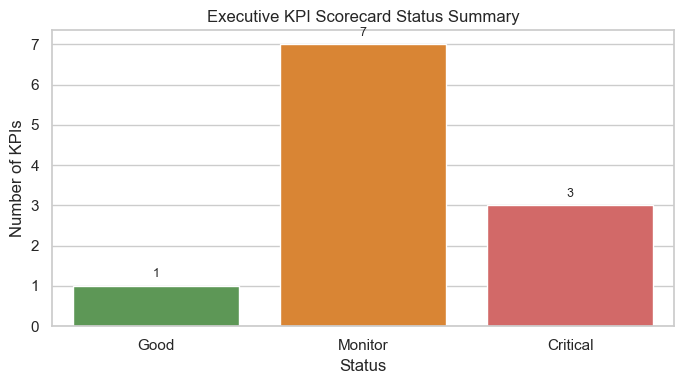

Executive Recommendation
Start with Critical KPIs and High Risk records, then use Monitor KPIs as leading indicators for the next maintenance planning cycle.


In [28]:
status_order = ["Good", "Monitor", "Critical"]
status_summary_df = kpi_scorecard_df["Status"].value_counts().reindex(status_order).fillna(0).reset_index()
status_summary_df.columns = ["Status", "KPI Count"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=status_summary_df, x="Status", y="KPI Count", order=status_order, ax=ax, palette=["#54A24B", "#F58518", "#E45756"])
annotate_bars(ax, status_summary_df["KPI Count"].tolist(), fmt="{:.0f}")
ax.set_title("Executive KPI Scorecard Status Summary")
ax.set_xlabel("Status")
ax.set_ylabel("Number of KPIs")
plt.tight_layout()
plt.show()

print("Executive Recommendation")
print("Start with Critical KPIs and High Risk records, then use Monitor KPIs as leading indicators for the next maintenance planning cycle.")